# Encoder tests: the photos against the encoder

Companion to the tests in this folder. In all of them the photos show where the stage
really is, and the encoder counts of the run are compared with that.

| part | test | what moves | photos |
|---|---|---|---|
| 1 - 4 | `24hrstest_can_linear.py`, `24hrstest_can_rotational.py`: 24 h, one run per encoder | to the **scale** and to the **sample** every 10 min | one per visit |
| 6 | `12hrstest_thermal_drift.py`: 12 h, linear encoder | nothing | one every 10 min |
| 7 | `test_xmas_tree_x.py`: growing zig-zag, linear encoder | 10 trees of 100 legs, each back to the start | before and after |

`dx`, `dy` = the shift of a photo against the first photo of its place / run, in um,
positive = right / down in the photo.

For the 24 h test nothing is correlated here: the shifts are read from
`<run>_shift.csv`, so run `24hrstest_shift.py <run>.csv` first. The photos of the other
two tests are correlated in this notebook (part 5). The encoder counts and the
lost-step events come from `<run>.csv`.

1. 24 h: the shift of the photos, with the lost-step events (4 plots)
2. 24 h: `dx` of both encoders in one plot, with the compensation zone (2 plots)
3. 24 h: encoder minus photo: did the encoder see the shift? (2 plots)
4. 24 h, more: what the compensation saw, where the unseen shift comes from, numbers
5. the shift of two photos by cross correlation, pixel size from the ruler
6. 12 h thermal drift: the shift when nothing moves, against the encoder and the 24 h test
7. xmas tree: the open-loop error after the zig-zag

In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 24 h test: run CSV and um per encoder count of each encoder. The sign turns the counts into the
# direction of dx (+ = picture to the right): the linear encoder counts up with the
# motor steps, the rotational one counts down (see "sign of the rotational encoder").
RUNS = {
    "linear": ("24hrstest_can_x_20261003_110333.csv", +1.95),
    "rotational": ("24hrstest_can_rotational_x_20261004_151450.csv", -0.25),
}
PLACES = ("scale", "sample")

# 12 h thermal drift test and xmas tree test, both with the linear encoder. Their photos
# are in <csv name>_photos: sorted by file name, the first one is the reference.
DRIFT_RUN = "12hrstest_thermal_drift_x_20261005_184730.csv"
XMAS_RUN = "xmas_tree_x_20261002_133550.csv"
TICK_UM = 10.0   # distance between two small ruler ticks in um  <-- CHECK YOUR SLIDE
# the drift photos have no ruler in them: their pixel size comes from this photo
RULER = "24hrstest_can_rotational_x_20261004_151450_photos/scale/0000_scale_20261004_151628.png"
UM_PER_PX = {"drift": None, "xmas": None}   # None = from the ruler (part 5), or set by hand

OUT_DIR = "encoder_test_plots"   # the plots are saved here (next to the CSVs), None = not saved

# the CSVs are in the folder the tests were started in: here or a folder above
DATA_DIR = next(d for p in (Path.cwd(), *Path.cwd().parents) for d in (p, p / "encoder_test_data")
                if (d / RUNS["linear"][0]).exists())

COLOR = {"dx": "#e34948", "dy": "#2a78d6", "lost": "#008300",
         "linear": "#eb6834", "rotational": "#4a3aa7", "zone": "#8a8984",
         "drift": "#1baf7a", "xmas": "#eda100", "enc": "#52514e"}
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "savefig.dpi": 150,
    "lines.linewidth": 1.6, "lines.markersize": 5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.7,
    "axes.titlesize": 11, "axes.titlelocation": "left", "legend.frameon": False,
})

## Data of the 24 h test

`enc` is what the encoder says about the same thing as `dx`: the raw count against the
raw count at the first photo of the place, times um per count.

In [2]:
def load(csv_name, um_per_count):
    """One run: the lost-step events and, per place, the photos as arrays."""
    with open(DATA_DIR / csv_name, newline="") as f:
        lines = f.readlines()
    header = "".join(l for l in lines if l.startswith("#"))
    rows = list(csv.DictReader(l for l in lines if not l.startswith("#")))
    with open(DATA_DIR / csv_name.replace(".csv", "_shift.csv"), newline="") as f:
        shifts = list(csv.DictReader(f))

    t_start = np.datetime64(min(r["time_iso"] for r in rows))   # as in 24hrstest_shift.py

    def hours(time_iso):
        return (np.datetime64(time_iso) - t_start) / np.timedelta64(1, "h")

    by_visit = {r["visit"]: r for r in rows}
    comp_counts = int(re.search(r"comp_counts=(\d+)", header).group(1))
    run = {
        "um_per_count": um_per_count,
        "comp_um": comp_counts * abs(um_per_count),   # half width of the compensation zone
        # the move in which the steps were lost; the photo of that visit is taken
        # right after the recovery
        "lost": [dict(hours=hours(r["xMoveStart"]), place=r["place"], steps=int(r["lostSteps"]))
                 for r in rows if r["event"]],
    }
    for place in PLACES:
        s = [r for r in shifts if r["place"] == place]
        raw = np.array([float(r["rawCounts"]) for r in s])
        event = np.array([bool(r["event"]) for r in s])
        run[place] = {
            "hours": np.array([float(r["hours"]) for r in s]),
            "dx": np.array([float(r["dx_um"]) for r in s]),
            "dy": np.array([float(r["dy_um"]) for r in s]),
            "enc": (raw - raw[0]) * um_per_count,
            # how far off the encoder was on arrival, before any correction, against
            # the first arrival at the place (which is what the compensation looks at)
            "drift": np.array([float(by_visit[r["visit"]]["encDriftCounts"]) for r in s]) * um_per_count,
            "event": event,
            # corrected because the encoder was out of the zone, no steps lost
            "comp": np.array([float(r["compSteps"]) != 0 for r in s]) & ~event,
        }
    return run


runs = {name: load(*args) for name, args in RUNS.items()}
for name, run in runs.items():
    print(f"{name:<11} {RUNS[name][0]}: {len(run['scale']['dx'])} scale + "
          f"{len(run['sample']['dx'])} sample photos, {len(run['lost'])} lost-step events, "
          f"compensation zone +-{run['comp_um']:.2f} um")


def new_plot(title, ylabel, hours=24):
    fig, ax = plt.subplots()
    ax.axhline(0, color="#52514e", lw=0.8)
    ax.set_title(title, pad=26)   # room for the legend between the title and the axes
    ax.set(ylabel=ylabel, xlabel="time since the start of the run [h]", xlim=(0, hours + 0.3))
    ax.set_xticks(range(0, hours + 1, hours // 12))
    return fig, ax


def mark_lost(ax, run):
    """A green dashed line at every lost-step event of the run."""
    for i, e in enumerate(run["lost"]):
        ax.axvline(e["hours"], color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                   label=f"lost steps ({len(run['lost'])} events)" if i == 0 else None)


def save(fig, name):
    if OUT_DIR:
        (DATA_DIR / OUT_DIR).mkdir(exist_ok=True)
        fig.savefig(DATA_DIR / OUT_DIR / f"{name}.png")
    plt.show()


def finish(fig, ax, name):
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=5, fontsize=9)
    fig.tight_layout()
    save(fig, name)

linear      24hrstest_can_x_20261003_110333.csv: 73 scale + 72 sample photos, 9 lost-step events, compensation zone +-9.75 um
rotational  24hrstest_can_rotational_x_20261004_151450.csv: 73 scale + 72 sample photos, 7 lost-step events, compensation zone +-9.75 um


## 1. Shift of the photos against the first one

One plot per encoder and place: `dx` (red) and `dy` (blue). The green dashed lines are
the lost-step events of the run, at the start of the move in which the steps were
lost. All events of the run are in both plots, also the ones on the way to the other
place. The y axis is not the same in the four plots.

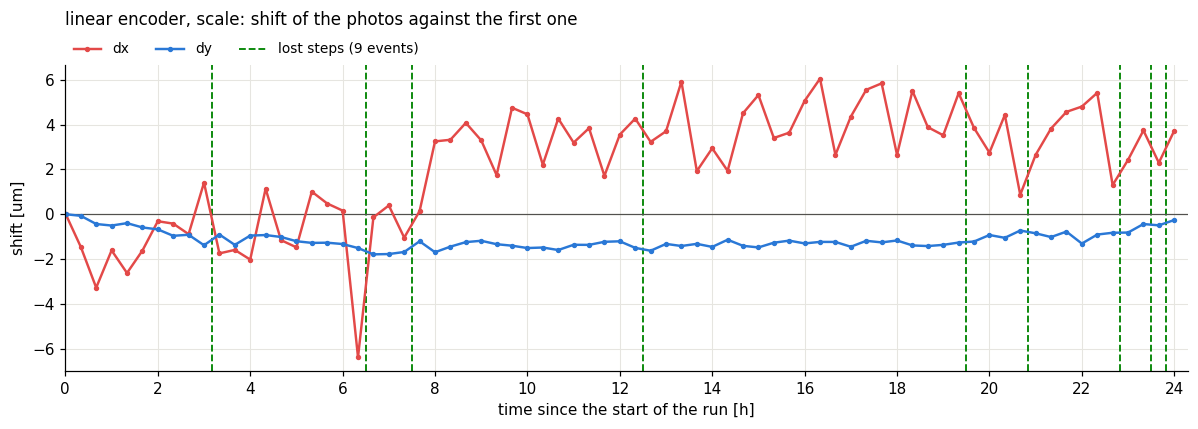

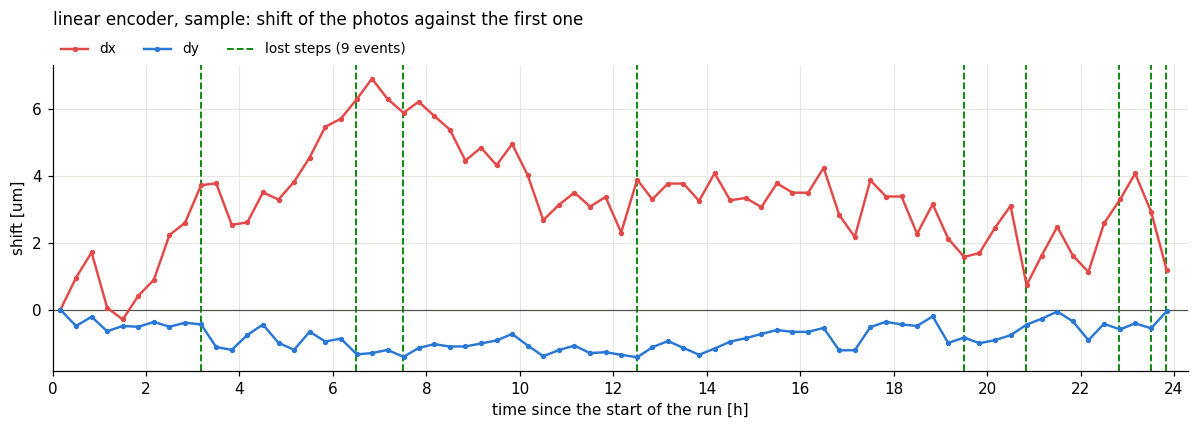

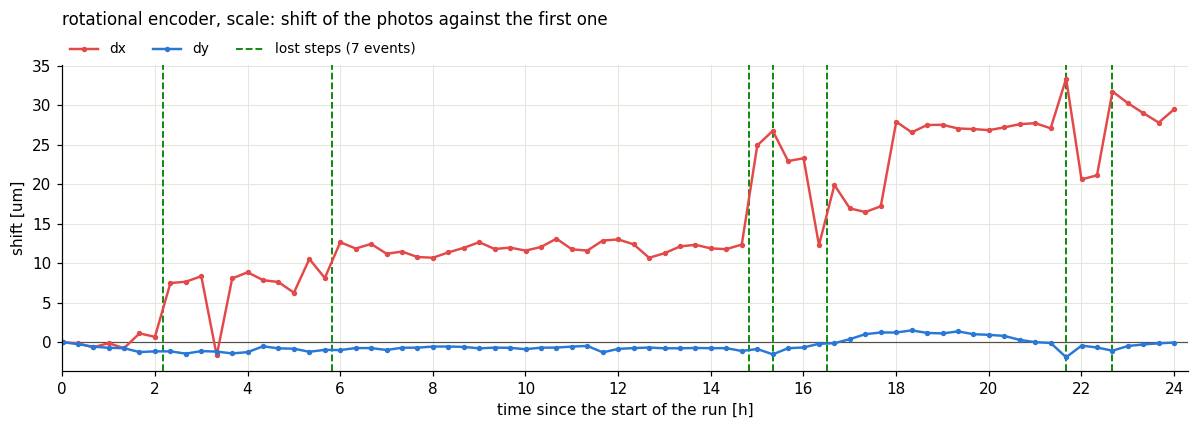

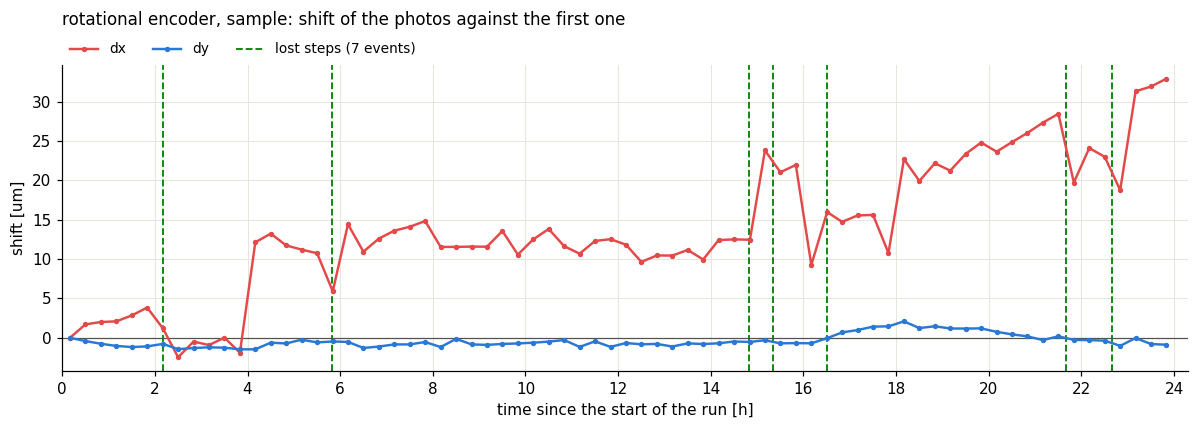

In [3]:
for name, run in runs.items():
    for place in PLACES:
        p = run[place]
        fig, ax = new_plot(f"{name} encoder, {place}: shift of the photos against the first one",
                           "shift [um]")
        ax.plot(p["hours"], p["dx"], ".-", color=COLOR["dx"], label="dx")
        ax.plot(p["hours"], p["dy"], ".-", color=COLOR["dy"], label="dy")
        mark_lost(ax, run)
        finish(fig, ax, f"1_shift_{name}_{place}")

## 2. dx of both encoders, with the compensation zone

The compensation only corrects X when the encoder is more than `comp_counts` off:
5 counts of the linear and 39 counts of the rotational encoder, both 9.75 um. The
zone is drawn around the first photo, like `dx`. The y axis is the same in both plots.

The zone of the test itself is around the encoder count at the *first arrival* at the
place, and that is the move before the first photo. For the rotational run at the
sample the two are 38 counts = 9.5 um apart (see 4.1), so there the real zone is not
centred on `dx = 0`.

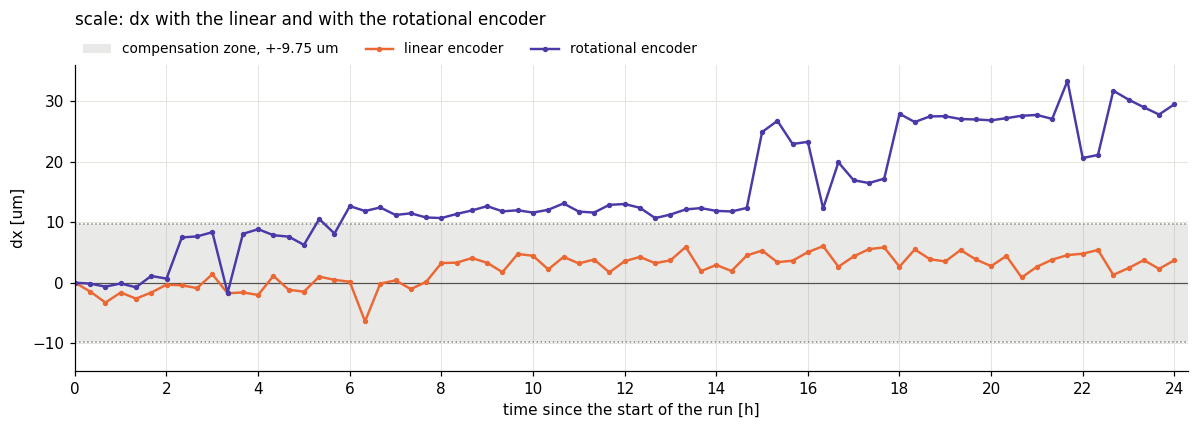

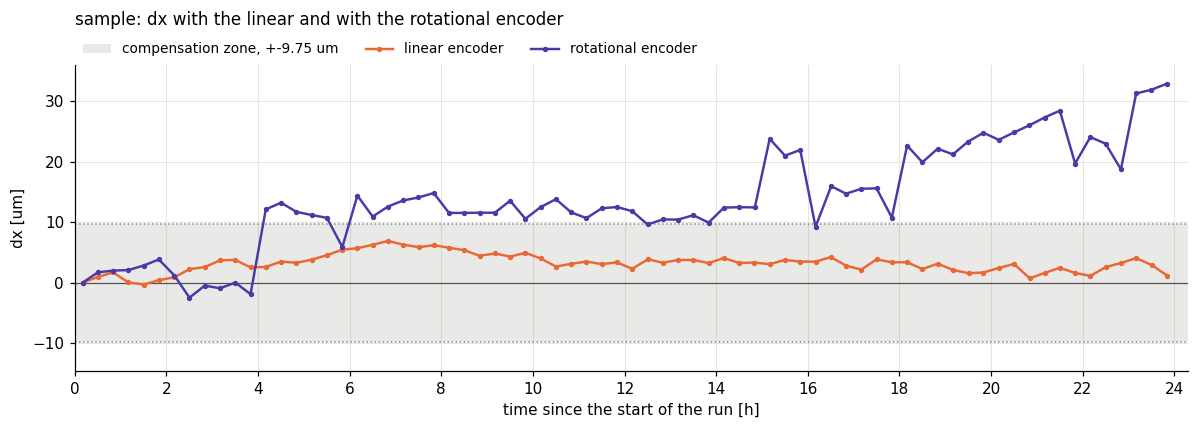

In [4]:
zone = runs["linear"]["comp_um"]
assert all(np.isclose(run["comp_um"], zone) for run in runs.values()), "not the same zone"
top = 1.08 * max(np.abs(run[place]["dx"]).max() for run in runs.values() for place in PLACES)

for place in PLACES:
    fig, ax = new_plot(f"{place}: dx with the linear and with the rotational encoder", "dx [um]")
    ax.axhspan(-zone, zone, color=COLOR["zone"], alpha=0.18, lw=0,
               label=f"compensation zone, +-{zone:.2f} um")
    for edge in (-zone, zone):
        ax.axhline(edge, color=COLOR["zone"], ls=":", lw=1)
    for name, run in runs.items():
        ax.plot(run[place]["hours"], run[place]["dx"], ".-", color=COLOR[name],
                label=f"{name} encoder")
    ax.set_ylim(-1.5 * zone, top)
    finish(fig, ax, f"2_dx_{place}")

## 3. Encoder minus photo: did the encoder see the shift?

`enc - dx`: the raw count against the first photo, times um per count (1.95 um
linear, 0.25 um rotational), minus the shift of the photo. 0 = the encoder reports
exactly what the photo shows; a value that stays away from 0 is a shift of the
picture the encoder does not know about.

### Sign of the rotational encoder

From the scale to the sample the motor goes -296010 steps in both runs. The linear
encoder goes from 0 to -47409 counts on the way, the rotational one from 0 to
+369981: it counts against the steps (-0.8 steps per count), so its counts are taken
with a minus sign here. The cell below checks it with the photos: the change of `dx`
from one photo to the next against the change of the count (a line through 0, over
all pairs of photos where the count changed).

In [5]:
for name, run in runs.items():
    counts = np.concatenate([np.diff(run[p]["enc"]) / run["um_per_count"] for p in PLACES])
    ddx = np.concatenate([np.diff(run[p]["dx"]) for p in PLACES])
    print(f"{name:<11} count changes up to {np.abs(counts).max():.0f}: dx moves "
          f"{(counts * ddx).sum() / (counts ** 2).sum():+.2f} um per count "
          f"(r = {np.corrcoef(counts[counts != 0], ddx[counts != 0])[0, 1]:+.2f}, "
          f"used: {run['um_per_count']:+.2f})")

linear      count changes up to 4: dx moves +0.96 um per count (r = +0.86, used: +1.95)
rotational  count changes up to 44: dx moves -0.27 um per count (r = -0.89, used: -0.25)


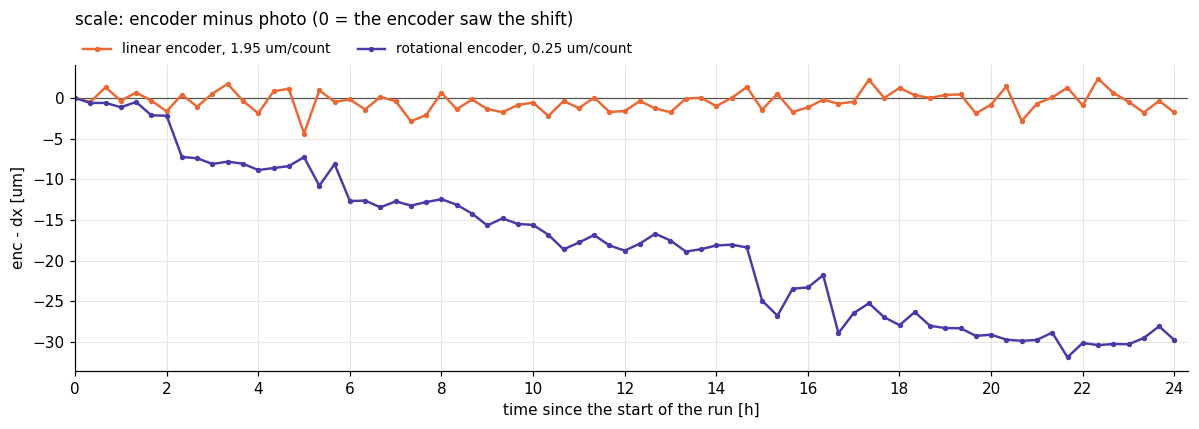

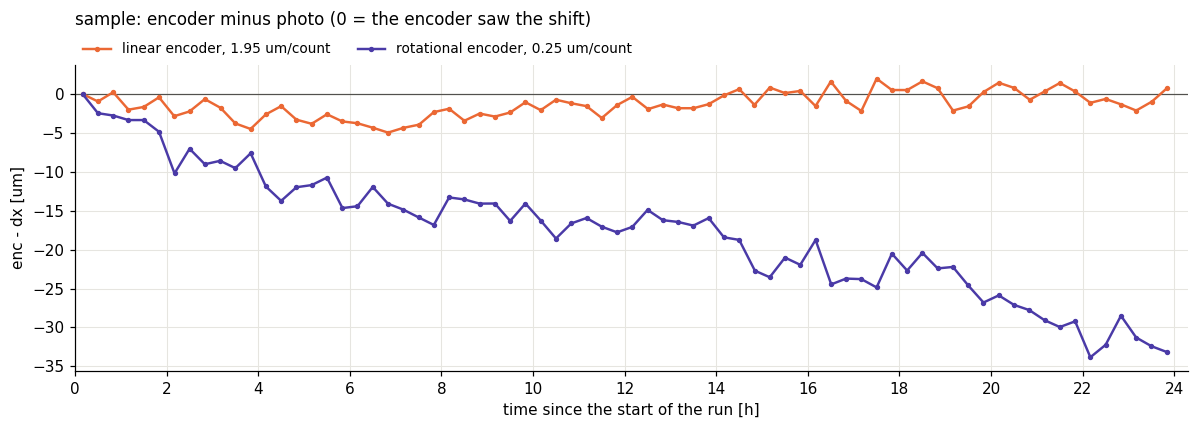

In [6]:
for place in PLACES:
    fig, ax = new_plot(f"{place}: encoder minus photo (0 = the encoder saw the shift)",
                       "enc - dx [um]")
    for name, run in runs.items():
        p = run[place]
        ax.plot(p["hours"], p["enc"] - p["dx"], ".-", color=COLOR[name],
                label=f"{name} encoder, {abs(run['um_per_count']):g} um/count")
    finish(fig, ax, f"3_encoder_minus_photo_{place}")

## 4. More

### 4.1 What the compensation saw

The encoder on arrival, before any correction, against the first arrival at the place
(`encDriftCounts` of the run, in um). This is the number the test compares with the
zone; the circles are the visits where it was outside and X was corrected. The visits
with lost steps are left out (thousands of counts off, they are the green lines of
part 1).

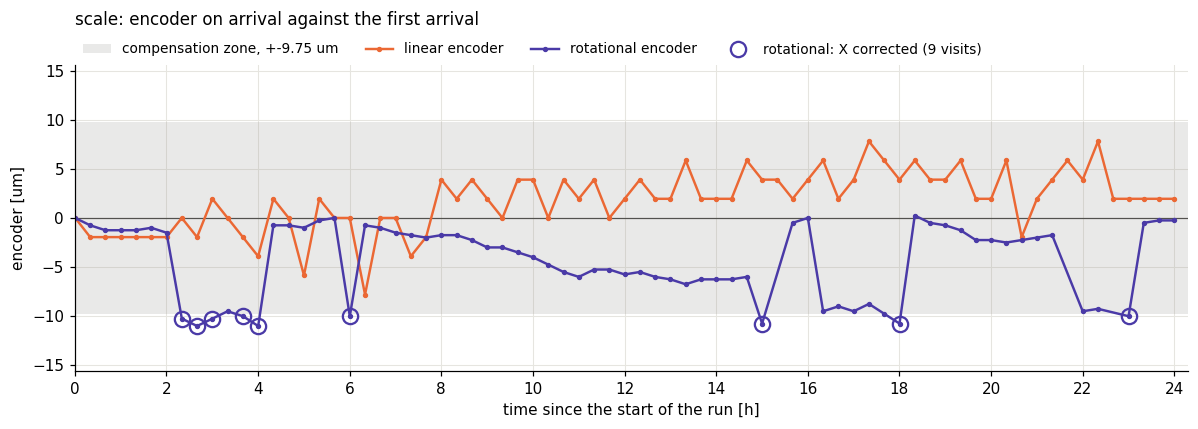

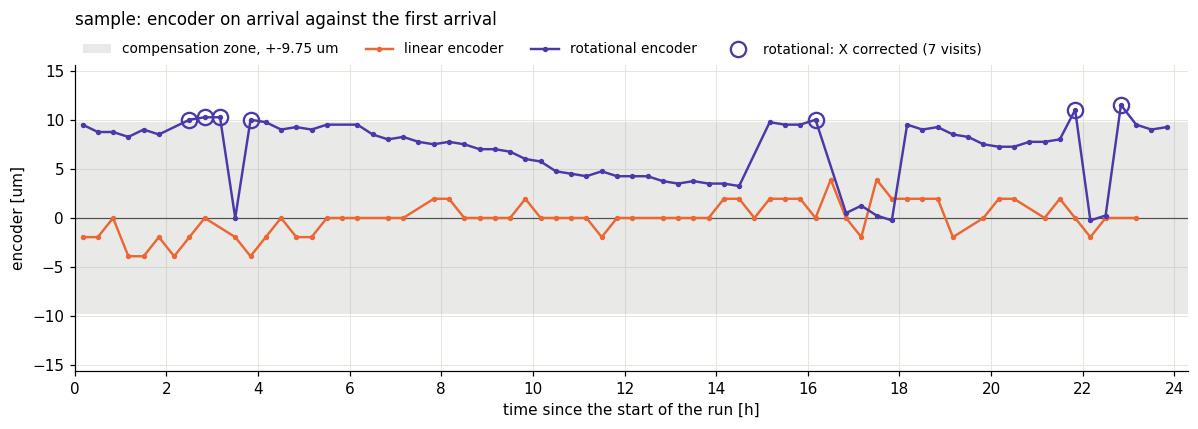

In [7]:
for place in PLACES:
    fig, ax = new_plot(f"{place}: encoder on arrival against the first arrival", "encoder [um]")
    ax.axhspan(-zone, zone, color=COLOR["zone"], alpha=0.18, lw=0,
               label=f"compensation zone, +-{zone:.2f} um")
    for name, run in runs.items():
        p = run[place]
        keep, comp = ~p["event"], p["comp"]
        ax.plot(p["hours"][keep], p["drift"][keep], ".-", color=COLOR[name], label=f"{name} encoder")
        if comp.any():
            ax.plot(p["hours"][comp], p["drift"][comp], "o", mfc="none", mec=COLOR[name], ms=10,
                    mew=1.5, label=f"{name}: X corrected ({comp.sum()} visits)")
    ax.set_ylim(-1.6 * zone, 1.6 * zone)
    finish(fig, ax, f"4_compensation_{place}")

### 4.2 Where does the unseen shift come from?

`enc - dx` of part 3 again, one plot per encoder, with the lost-step events. A step
at a green line = the recovery left the stage at another place than the encoder
thinks; a slope between the lines = slow drift (temperature) the encoder cannot see.

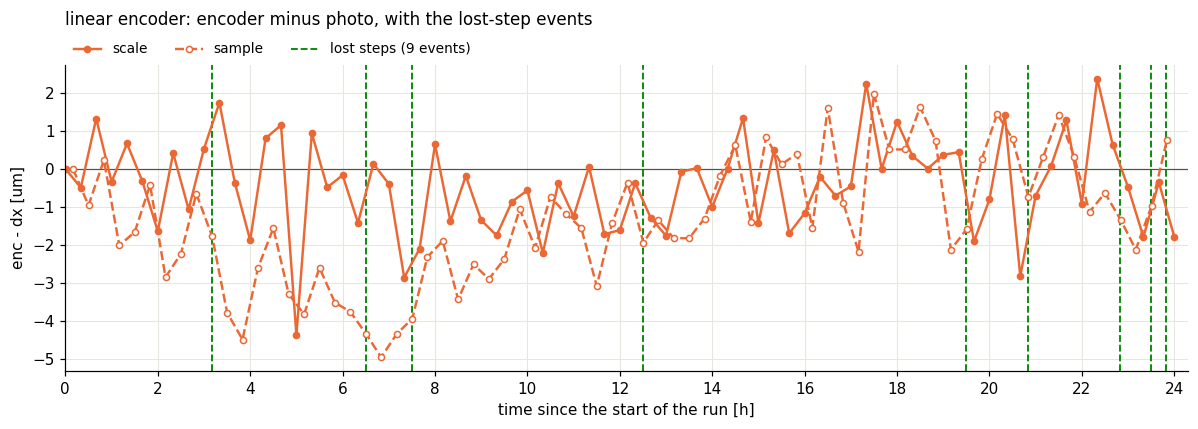

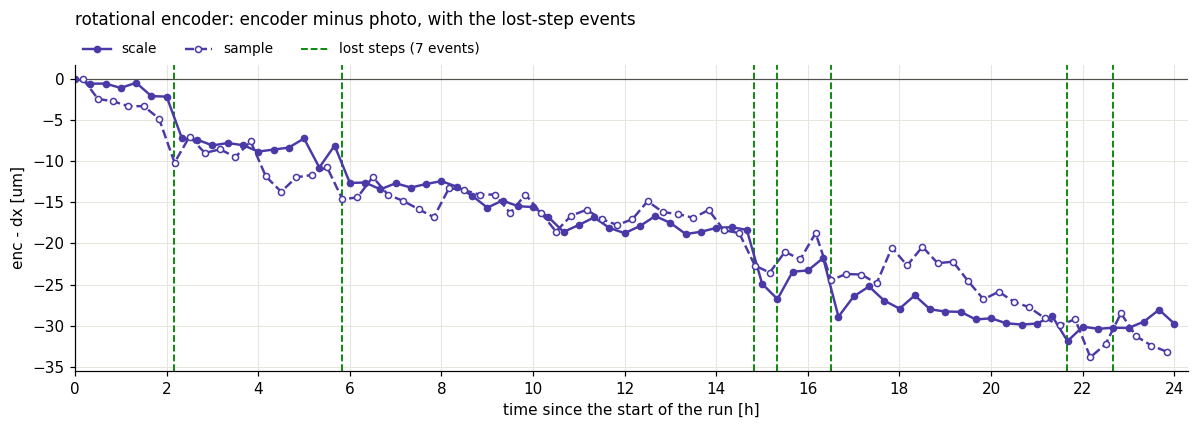

In [8]:
for name, run in runs.items():
    fig, ax = new_plot(f"{name} encoder: encoder minus photo, with the lost-step events",
                       "enc - dx [um]")
    for place, style in zip(PLACES, (dict(ls="-"), dict(ls="--", mfc="white"))):
        p = run[place]
        ax.plot(p["hours"], p["enc"] - p["dx"], "o", color=COLOR[name], ms=4, label=place, **style)
    mark_lost(ax, run)
    finish(fig, ax, f"4_unseen_shift_{name}")

### 4.3 Numbers

`at lost` = rms change of `enc - dx` between two photos of a place with a lost-step
event of the run in between, `else` = the same for all other pairs of photos.
`lost` = events on the way to this place, `corr.` = visits where X was corrected
because the encoder was out of the zone.

In [9]:
def rms(v):
    return f"{np.sqrt((v ** 2).mean()):.2f}" if v.size else "-"


print(f"{'[um]':<18} {'dx min':>7} {'dx max':>7} {'dx end':>7} {'dy min':>7} {'dy max':>7}   "
      f"{'enc - dx: rms':>13} {'end':>7} {'at lost':>8} {'else':>6}   {'lost':>4} {'corr.':>5}")
for name, run in runs.items():
    t = np.array([e["hours"] for e in run["lost"]])
    for place in PLACES:
        p = run[place]
        unseen = p["enc"] - p["dx"]
        step = np.diff(unseen)
        across = np.array([((t > a) & (t <= b)).any() for a, b in zip(p["hours"], p["hours"][1:])])
        print(f"{name:<10} {place:<7} {p['dx'].min():>7.2f} {p['dx'].max():>7.2f} {p['dx'][-1]:>7.2f} "
              f"{p['dy'].min():>7.2f} {p['dy'].max():>7.2f}   {rms(unseen):>13} {unseen[-1]:>7.2f} "
              f"{rms(step[across]):>8} {rms(step[~across]):>6}   "
              f"{sum(e['place'] == place for e in run['lost']):>4} {p['comp'].sum():>5}")

[um]                dx min  dx max  dx end  dy min  dy max   enc - dx: rms     end  at lost   else   lost corr.
linear     scale     -6.39    6.05    3.73   -1.79    0.00            1.30   -1.78     1.52   1.85      0     0
linear     sample    -0.29    6.90    1.19   -1.42    0.00            2.12    0.76     1.14   1.43      9     0
rotational scale     -1.68   33.38   29.51   -1.91    1.50           20.22  -29.76     4.67   1.16      3     9
rotational sample    -2.47   32.91   32.91   -1.46    2.09           19.46  -33.16     4.02   1.83      4     7


## 5. Shift of two photos by cross correlation

For the 12 h drift test and the xmas tree test the photos are compared here: every photo
of a run with the first one. The shift is found by cross correlation of the two images
(FFT, sub-pixel peak by a parabola fit), the same way as `24hrstest_shift.py` does it
for the 24 h test. `corr` is the height of the correlation peak: 1 = the same picture,
only shifted.

Correlating takes about 3 s per photo, so the shifts in px are kept in
`<run>_shift.csv` next to the run; delete that file to measure again.

In [10]:
IMAGE_EXT = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")


def load_gray(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)


def tick_period(im, bands=32, min_lag=5):
    """(period of the small ruler ticks in px, the autocorrelation it is read from).
    The photo is cut into horizontal bands and the intensity profile along x of each
    band is autocorrelated: the bands across the small ticks have the shortest period."""
    found = []
    for rows in np.array_split(im, bands):
        prof = rows.mean(axis=0)
        prof = (prof - prof.mean()) * np.hanning(prof.size)
        ac = np.fft.irfft(np.abs(np.fft.rfft(prof, 2 * prof.size)) ** 2)[:prof.size // 2]
        ac /= ac[0]
        # the peaks of a periodic profile: maxima well above the valley before them
        low = np.minimum.accumulate(ac)
        peaks = [i for i in range(min_lag, ac.size - 1)
                 if ac[i] > ac[i - 1] and ac[i] >= ac[i + 1] and ac[i] > 0.3 and ac[i] - low[i] > 0.3]
        if peaks:
            found.append((peaks, ac))
    assert found, "no ruler ticks found in the photo, set UM_PER_PX by hand"
    # of the bands with the shortest period, the one with the clearest peak
    first = min(peaks[0] for peaks, ac in found)
    peaks, ac = max((f for f in found if f[0][0] <= 1.1 * first), key=lambda f: f[1][f[0][0]])
    # the peaks at 2, 3, ... periods give the period more exactly: follow them as long
    # as the next one is where it should be
    n, i = 1, peaks[0]
    for p in peaks[1:]:
        if abs(p - (n + 1) * i / n) > 0.1 * peaks[0]:
            break
        n, i = n + 1, p
    # parabola through the 3 points around the peak
    return (i + 0.5 * (ac[i - 1] - ac[i + 1]) / (ac[i - 1] - 2 * ac[i] + ac[i + 1])) / n, ac


class Reference:
    """The first photo of a run; shift() compares another photo with it."""

    def __init__(self, ref, highpass_px=100):
        self.shape = h, w = ref.shape
        self.win = np.outer(np.hanning(h), np.hanning(w)).astype(np.float32)
        # drop the slow background (vignetting does not move with the stage)
        fy = np.fft.fftfreq(h)[:, None]
        fx = np.fft.rfftfreq(w)[None, :]
        self.keep = np.hypot(fx, fy) >= 1 / highpass_px
        self.A = self.spectrum(ref)
        self.energy = self.sum_sq(self.A)

    def spectrum(self, im):
        return np.fft.rfft2((im - im.mean()) * self.win) * self.keep

    def sum_sq(self, F):
        """Sum of the squared pixels of the filtered image (Parseval; the half spectrum
        of rfft2 holds every column but the first and the Nyquist one twice)."""
        p = np.abs(F) ** 2
        h, w = self.shape
        full = 2 * p.sum() - p[:, 0].sum() - (p[:, -1].sum() if w % 2 == 0 else 0)
        return full / (h * w)

    def shift(self, img):
        """(dx, dy, corr, correlation map) of img relative to the reference."""
        assert img.shape == self.shape, "photos must all have the same size"
        h, w = self.shape
        B = self.spectrum(img)
        cc = np.fft.irfft2(np.conj(self.A) * B, s=self.shape)
        py, px = np.unravel_index(np.argmax(cc), cc.shape)

        def subpixel(cm, c0, cp):
            return 0.5 * (cm - cp) / (cm - 2 * c0 + cp)

        dy = py + subpixel(cc[py - 1, px], cc[py, px], cc[(py + 1) % h, px])
        dx = px + subpixel(cc[py, px - 1], cc[py, px], cc[py, (px + 1) % w])
        if dy > h / 2:
            dy -= h
        if dx > w / 2:
            dx -= w
        return float(dx), float(dy), float(cc[py, px] / np.sqrt(self.energy * self.sum_sq(B))), cc


def photos_of(csv_name):
    folder = DATA_DIR / csv_name.replace(".csv", "_photos")
    files = sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXT)
    assert len(files) >= 2, f"need at least 2 photos in {folder}"
    return files


def photo_shifts(csv_name):
    """dx_px, dy_px, corr of every photo of the run against the first one, as arrays:
    from <csv name>_shift.csv if it was made from these photos, measured otherwise."""
    files, keys = photos_of(csv_name), ("dx_px", "dy_px", "corr")
    out = DATA_DIR / csv_name.replace(".csv", "_shift.csv")
    rows = []
    if out.exists():
        with open(out, newline="") as f:
            rows = list(csv.DictReader(f))
    if [r["photo"] for r in rows] != [p.name for p in files]:
        ref = Reference(load_gray(files[0]))
        rows = []
        for p in files:
            dx, dy, corr, _ = ref.shift(load_gray(p))
            rows.append(dict(photo=p.name, dx_px=round(dx, 3), dy_px=round(dy, 3), corr=round(corr, 4)))
        with open(out, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=rows[0].keys())
            w.writeheader()
            w.writerows(rows)
    return {k: np.array([float(r[k]) for r in rows]) for k in keys}


def visual_check(csv_name, um_per_px, name, i=-1, z=40):
    """Photo i of the run against the first one. Left: overlay of the image centre, the
    first photo in red, photo i in cyan. Right: the correlation around its peak, +-z px."""
    files = photos_of(csv_name)
    ref, im = load_gray(files[0]), load_gray(files[i])
    dx, dy, corr, cc = Reference(ref).shift(im)
    h, w = ref.shape
    ys, xs = slice(h // 2 - h // 6, h // 2 + h // 6), slice(w // 2 - w // 6, w // 2 + w // 6)

    def norm(a):
        return (a - a.min()) / (a.max() - a.min())

    fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.6), width_ratios=(1.5, 1), layout="constrained")
    a0.imshow(np.dstack([norm(ref[ys, xs]), norm(im[ys, xs]), norm(im[ys, xs])]))
    a0.set_title(f"red: {files[0].name}\ncyan: {files[i].name}")
    a0.axis("off")
    a1.imshow(np.fft.fftshift(cc)[h // 2 - z:h // 2 + z + 1, w // 2 - z:w // 2 + z + 1],
              extent=(-z - .5, z + .5, z + .5, -z - .5), cmap="viridis")
    a1.plot(dx, dy, "+", color=COLOR["dx"], ms=14, mew=1.5)
    a1.set_title(f"dx = {dx:+.2f} px = {dx * um_per_px:+.2f} um\n"
                 f"dy = {dy:+.2f} px = {dy * um_per_px:+.2f} um")
    a1.set(xlabel="dx [px]", ylabel="dy [px]")
    a1.grid(False)
    save(fig, name)

### 5.1 Pixel size from the ruler

Autocorrelation of the intensity profile along x, across the small ticks of a photo
with the ruler in it: the first peak is the tick period in px, one tick is `TICK_UM`. The xmas tree photos show
the ruler themselves; the drift photos do not, their pixel size comes from the first
scale photo of the last 24 h run before (`RULER`, same microscope). Check in the plot
that the marked peak is really the small-tick period; if not, set `UM_PER_PX` by hand.

drift 0000_scale_20261004_151628.png: tick period = 83.85 px -> 0.1193 um/px (used: 0.1193)
xmas  Image_20261002133603729.bmp: tick period = 83.77 px -> 0.1194 um/px (used: 0.1194)


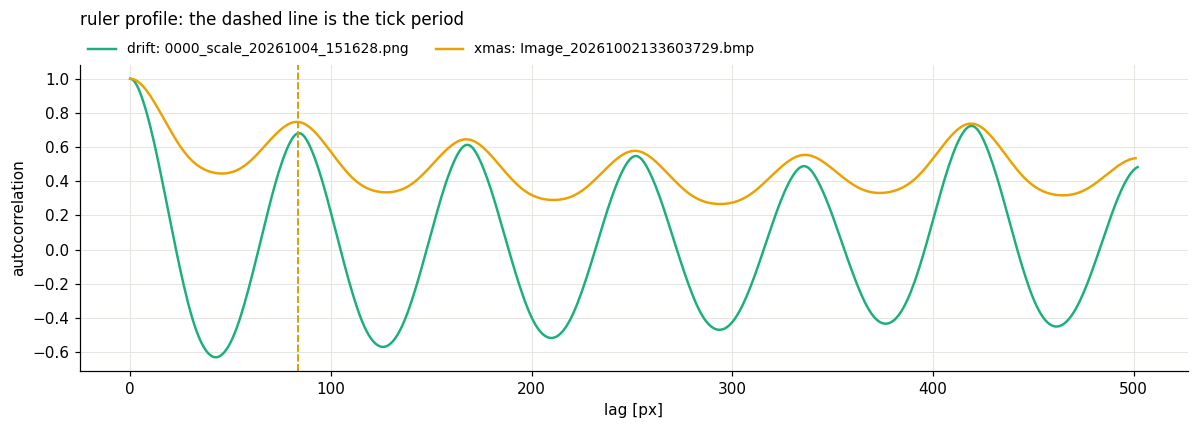

In [11]:
rulers = {"drift": DATA_DIR / RULER, "xmas": photos_of(XMAS_RUN)[0]}
um_per_px = {}
fig, ax = plt.subplots()
ax.set_title("ruler profile: the dashed line is the tick period", pad=26)
for name, path in rulers.items():
    period, ac = tick_period(load_gray(path))
    um_per_px[name] = UM_PER_PX[name] or TICK_UM / period
    print(f"{name:<5} {path.name}: tick period = {period:.2f} px -> {TICK_UM / period:.4f} um/px "
          f"(used: {um_per_px[name]:.4f})")
    ax.plot(ac[:int(period * 6)], color=COLOR[name], label=f"{name}: {path.name}")
    ax.axvline(period, color=COLOR[name], ls="--", lw=1.2)
ax.set(xlabel="lag [px]", ylabel="autocorrelation")
finish(fig, ax, "5_ruler")

## 6. 12 h thermal drift: nothing moves

`12hrstest_thermal_drift.py`: the stage is left where it is for 12 h, every 10 min a
photo is taken and the linear encoder and the step counters are read. No move is sent,
so what `dx` and `dy` show here is not the motor: it is the drift of the microscope
and of the sample (temperature), the part of the shifts of the 24 h test that no
encoder on the X axis can correct.

`enc` is as in the 24 h test: the raw count against the count at the first photo,
times 1.95 um.

In [12]:
def load_drift(csv_name, um_per_count, um_per_px):
    """The 12 h run: the samples that have a photo, as arrays."""
    with open(DATA_DIR / csv_name, newline="") as f:
        rows = {int(r["sample"]): r for r in csv.DictReader(l for l in f if not l.startswith("#"))}
    # file names start with the sample: 0019_<time>.png
    s = [rows[int(p.name.split("_")[0])] for p in photos_of(csv_name)]
    shifts = photo_shifts(csv_name)
    raw = np.array([float(r["rawCounts"] or "nan") for r in s])
    return {
        "hours": np.array([float(r["elapsed_s"]) for r in s]) / 3600,
        "dx": shifts["dx_px"] * um_per_px,
        "dy": shifts["dy_px"] * um_per_px,
        "corr": shifts["corr"],
        "counts": raw - raw[0],
        "enc": (raw - raw[0]) * um_per_count,
        # the step counters of X, Y and Z: they must not change
        "steps": {(r["commanded"], r["y"], r["z"]) for r in s},
    }


drift = load_drift(DRIFT_RUN, RUNS["linear"][1], um_per_px["drift"])
print(f"{DRIFT_RUN}: {len(drift['dx'])} photos in {drift['hours'][-1]:.1f} h, "
      f"corr {drift['corr'][1:].min():.2f} .. {drift['corr'][1:].max():.2f}, the step counters of "
      f"X, Y, Z {'did not change' if len(drift['steps']) == 1 else 'CHANGED: something moved'}")

12hrstest_thermal_drift_x_20261005_184730.csv: 73 photos in 12.0 h, corr 0.77 .. 0.90, the step counters of X, Y, Z did not change


### 6.1 Shift of the photos against the first one

`dx` (red) and `dy` (blue) as in part 1, here with nothing moving in between.

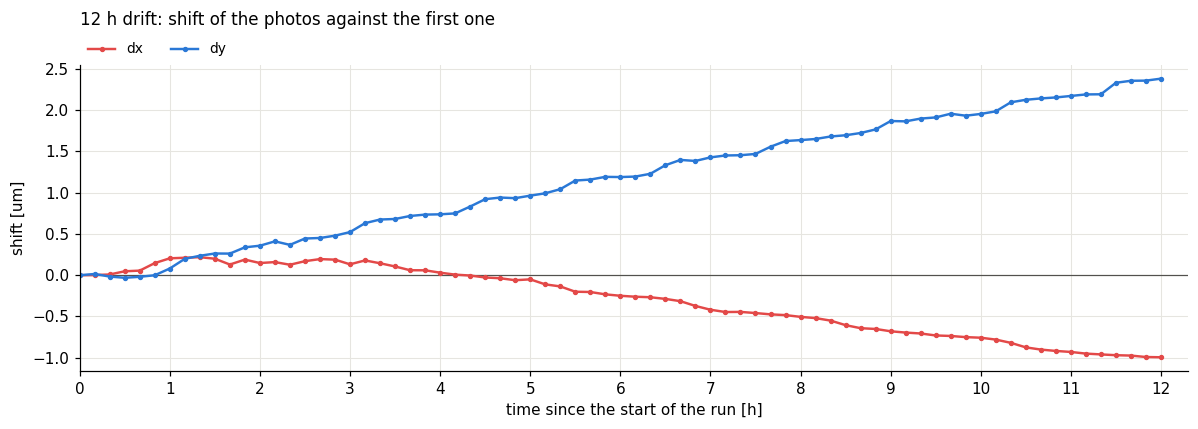

In [13]:
fig, ax = new_plot("12 h drift: shift of the photos against the first one", "shift [um]", hours=12)
ax.plot(drift["hours"], drift["dx"], ".-", color=COLOR["dx"], label="dx")
ax.plot(drift["hours"], drift["dy"], ".-", color=COLOR["dy"], label="dy")
finish(fig, ax, "6_drift_shift")

### 6.2 Encoder against the photo

`enc` (points) and `dx` (line) in one plot: what the linear encoder reports and what
the photo shows. One count is 1.95 um, so a drift below that can only show as the count
going back and forth between two neighbours.

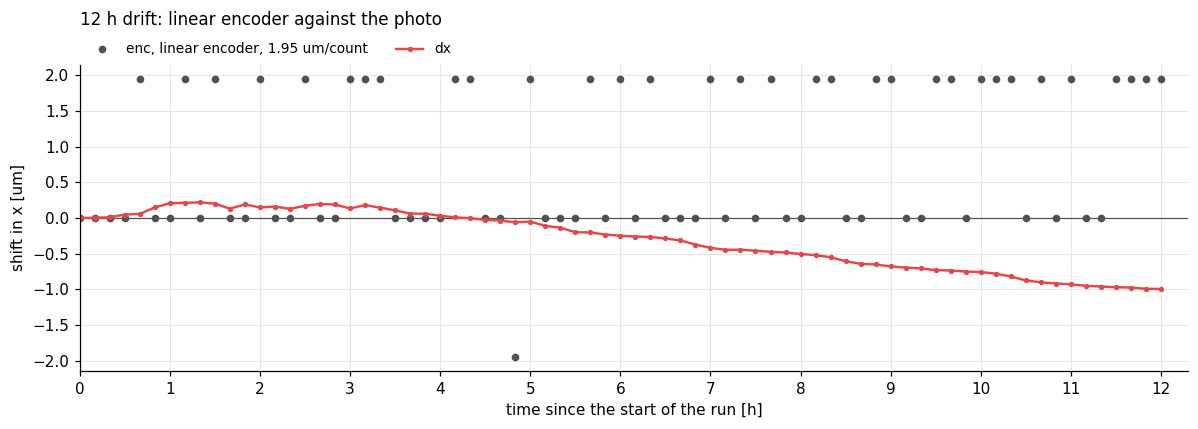

In [14]:
fig, ax = new_plot("12 h drift: linear encoder against the photo", "shift in x [um]", hours=12)
ax.plot(drift["hours"], drift["enc"], "o", color=COLOR["enc"], ms=4,
        label=f"enc, linear encoder, {abs(RUNS['linear'][1]):g} um/count")
ax.plot(drift["hours"], drift["dx"], ".-", color=COLOR["dx"], label="dx")
finish(fig, ax, "6_drift_encoder")

### 6.3 Against the 24 h test

`dx` and `dy` of the drift run in one plot with the sample photos of the two 24 h runs,
all against the time since the start of their run. The runs started at different times
of the day (24 h: 11:03 and 15:14, drift: 18:47), so the curves are not expected to lie
on each other: the plots show how large the shift is that needs no move at all.

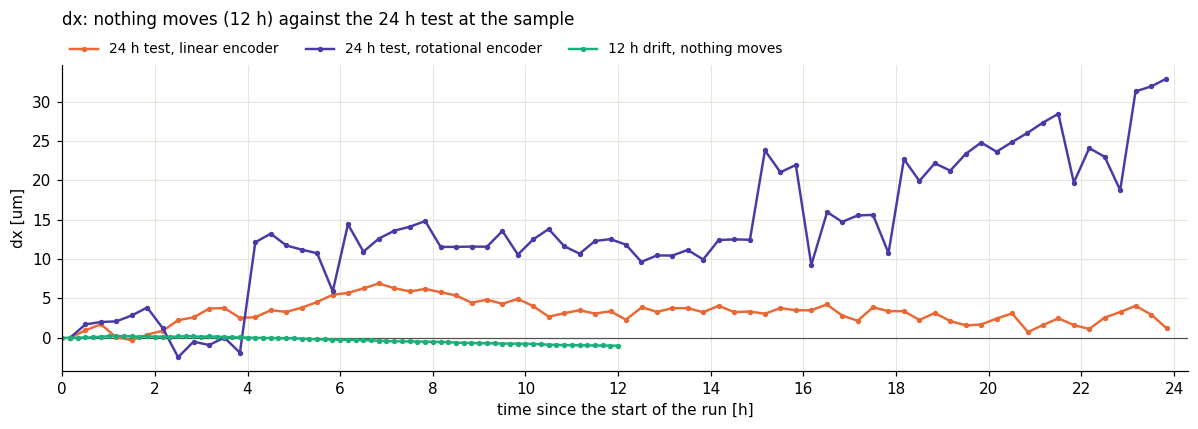

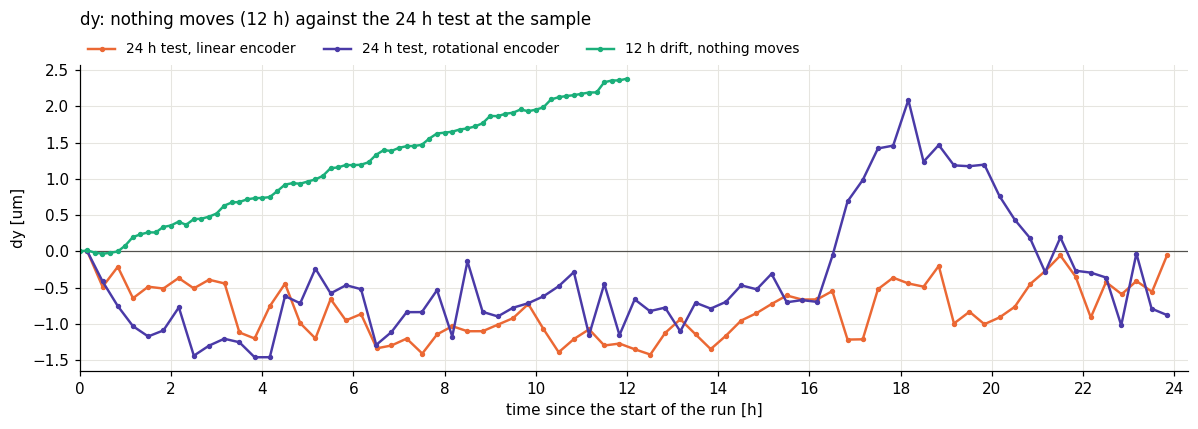

In [15]:
for axis in ("dx", "dy"):
    fig, ax = new_plot(f"{axis}: nothing moves (12 h) against the 24 h test at the sample", f"{axis} [um]")
    for name, run in runs.items():
        ax.plot(run["sample"]["hours"], run["sample"][axis], ".-", color=COLOR[name],
                label=f"24 h test, {name} encoder")
    ax.plot(drift["hours"], drift[axis], ".-", color=COLOR["drift"], label="12 h drift, nothing moves")
    finish(fig, ax, f"6_drift_against_24h_{axis}")

### 6.4 Numbers

`step` = rms change from one photo to the next: with nothing moving this is the noise
of the measurement plus 10 min of drift, in the 24 h test it also holds the error of
going away and coming back. `um/h` = slope of a line through the 12 h. The rows of the
24 h test are the sample photos of the first 12 h.

In [16]:
def drift_row(label, p, keep=slice(None)):
    out = f"{label:<28}"
    for axis in ("dx", "dy"):
        v, t = p[axis][keep], p["hours"][keep]
        out += (f" {v.min():>7.2f} {v.max():>7.2f} {v[-1]:>7.2f} {np.polyfit(t, v, 1)[0]:>7.3f} "
                f"{rms(np.diff(v)):>7}  ")
    print(out)


print(f"{'[um]':<28}" + "".join(f" {a + ' min':>7} {a + ' max':>7} {a + ' end':>7} {'um/h':>7} {'step':>7}  "
                                for a in ("dx", "dy")))
drift_row("12 h drift, nothing moves", drift)
for name, run in runs.items():
    drift_row(f"24 h test, {name}, 12 h", run["sample"], run["sample"]["hours"] <= 12.2)

c, late = drift["counts"], drift["hours"] >= 6
print(f"\nencoder: raw count {c.min():+.0f} .. {c.max():+.0f} against the first photo, not 0 in "
      f"{(c[~late] != 0).sum()} of {(~late).sum()} samples of the first 6 h and in "
      f"{(c[late] != 0).sum()} of {late.sum()} of the last 6 h; enc - dx: rms "
      f"{rms(drift['enc'] - drift['dx'])} um")

[um]                          dx min  dx max  dx end    um/h    step    dy min  dy max  dy end    um/h    step  
12 h drift, nothing moves      -0.99    0.22   -0.99  -0.110    0.03     -0.03    2.38    2.38   0.207    0.05  
24 h test, linear, 12 h        -0.29    6.90    2.31   0.291    0.75     -1.41    0.00   -1.35  -0.080    0.28  
24 h test, rotational, 12 h    -2.47   14.83   11.83   1.203    3.27     -1.46    0.00   -0.66   0.019    0.44  

encoder: raw count -1 .. +1 against the first photo, not 0 in 13 of 36 samples of the first 6 h and in 20 of 37 of the last 6 h; enc - dx: rms 1.63 um


### 6.5 Visual check

The last photo against the first one. Left: overlay of the image centre, the first
photo in red, the last one in cyan - where they agree it is grey / black, a shift shows
up as coloured fringes. Right: the correlation peak (should be one clean maximum).

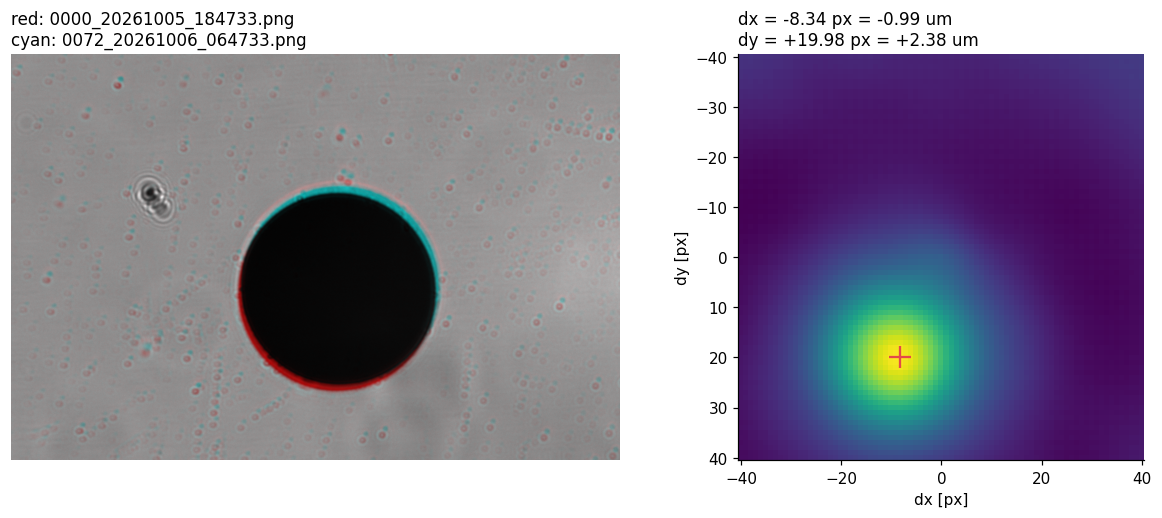

In [17]:
visual_check(DRIFT_RUN, um_per_px["drift"], "6_drift_check")

## 7. Xmas tree: open-loop error after the zig-zag

`test_xmas_tree_x.py`: from the start position the axis goes left 2000 steps, right
4000, left 6000, ... up to 200000 and back to the start, 10 times, open loop. One photo
of the calibration slide is taken before the first tree and one after the last: the
shift between them is the accumulated open-loop error. All photos in the folder are
compared with the first one (`0_before_a`, `0_before_b` without moving in between
gives the noise floor of the measurement).

The run tells the rest: the raw count every time the axis is back at the start, and the
stage travel per motor step (from the longest leg), to express the error in steps.

In [18]:
with open(DATA_DIR / XMAS_RUN, newline="") as f:
    rows = list(csv.DictReader(l for l in f if not l.startswith("#")))
um_per_count = RUNS["linear"][1]
# the encoder with the axis back at the start: before the first tree and after every tree
home = np.array([int(r["rawCounts"]) for r in rows if r["leg"] in ("start", "return")])
home -= home[0]
# stage travel per motor step, from the longest leg of the run
steps, counts = max(((int(r["move"]), int(r["rawCounts"]) - int(q["rawCounts"]))
                     for q, r in zip(rows, rows[1:])), key=lambda leg: abs(leg[0]))
um_per_step = counts * um_per_count / steps
print(f"{XMAS_RUN}: {len(home) - 1} trees, one step = {um_per_step:.4f} um "
      f"({steps:+d} steps = {counts:+d} counts)")
print(f"encoder back at the start after each tree [counts]: {' '.join(f'{c:+d}' for c in home[1:])}\n")

files, s, k = photos_of(XMAS_RUN), photo_shifts(XMAS_RUN), um_per_px["xmas"]
print(f"{'photo':<28} {'dx [px]':>8} {'dy [px]':>8} {'dx [um]':>8} {'dy [um]':>8} {'|d| [um]':>8} "
      f"{'|d| [steps]':>11} {'corr':>5}")
for p, dx, dy, corr in list(zip(files, s["dx_px"], s["dy_px"], s["corr"]))[1:]:
    d = np.hypot(dx, dy) * k
    print(f"{p.name:<28} {dx:>8.2f} {dy:>8.2f} {dx * k:>8.2f} {dy * k:>8.2f} {d:>8.2f} "
          f"{d / abs(um_per_step):>11.1f} {corr:>5.2f}")
enc = home[-1] * um_per_count
print(f"\nlast photo: enc = {enc:+.2f} um, enc - dx = {enc - s['dx_px'][-1] * k:+.2f} um")
print(f"(reference: {files[0].name}; one tick = {TICK_UM / k:.1f} px - a shift close to a multiple "
      "of that may be a wrong correlation peak, check the overlay below)")

xmas_tree_x_20261002_133550.csv: 10 trees, one step = 0.3126 um (+200000 steps = +32060 counts)
encoder back at the start after each tree [counts]: +0 +1 +0 -1 -1 +0 +1 +2 +0 +0

photo                         dx [px]  dy [px]  dx [um]  dy [um] |d| [um] |d| [steps]  corr
Image_20261002143426132.bmp      5.97    -1.83     0.71    -0.22     0.75         2.4  0.70

last photo: enc = +0.00 um, enc - dx = -0.71 um
(reference: Image_20261002133603729.bmp; one tick = 83.8 px - a shift close to a multiple of that may be a wrong correlation peak, check the overlay below)


### 7.1 Visual check

Every photo against the first one, as in 6.5. The correlation map is two tick periods
wide here: the peaks next to the marked one are the ruler ticks one period further.

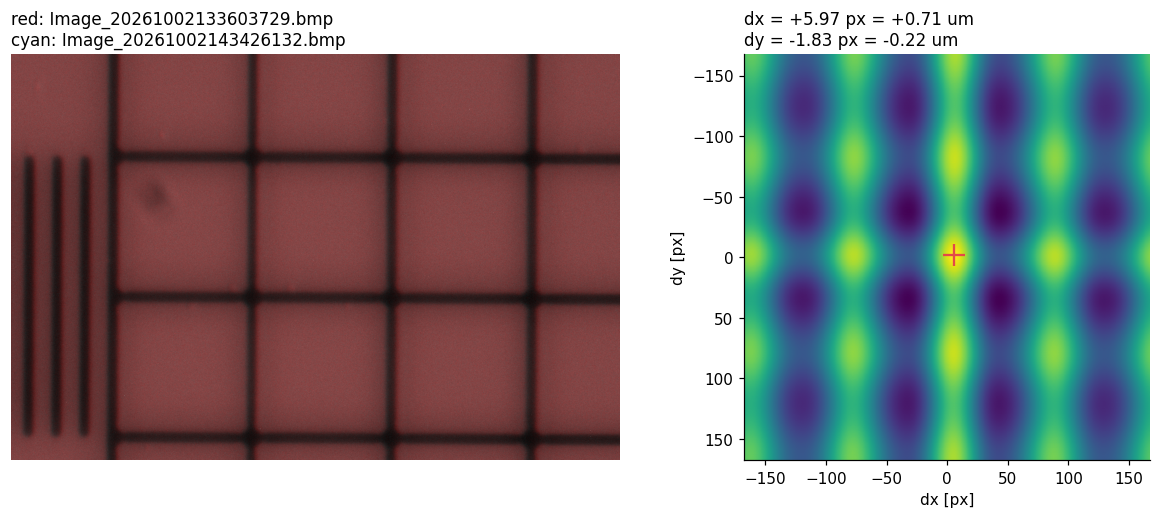

In [19]:
for i in range(1, len(files)):
    visual_check(XMAS_RUN, k, f"7_xmas_check_{i}", i, z=int(2 * TICK_UM / k))